# Classificazione del testo
La classificazione è uno dei problemi fondamentali dell’apprendimento supervisionato.
Consiste nell’assegnare a un elemento (detto istanza) una classe fra un insieme finito di categorie possibili, sulla base delle sue caratteristiche osservabili (dette feature o attributi).

In pratica, un modello di classificazione impara — a partire da un insieme di esempi etichettati — una regola che associa le feature di input a una o più etichette di output. Una volta addestrato, il modello può essere utilizzato per predire la classe di nuovi esempi non ancora visti.

### Classificazione binaria e non binaria

**Classificazione binaria**: 
In questo caso l’insieme delle classi possibili è costituito da due sole categorie, ad esempio “positivo/negativo”, “vero/falso”, “spam/non spam”.
Il modello impara a discriminare tra due stati o condizioni opposte.

**Classificazione non binaria (multiclasse o multilabel)**: 
Quando le classi possibili sono più di due, si parla di classificazione multiclasse o multilabel.
Esempi tipici sono il riconoscimento del tipo di animale in mammifero, uccello, pesce, ecc. o la classificazione tematica di un testo.

### Classificazione partitiva (hard) e non partitiva (soft)

Un'altra distinzione importante riguarda il modo in cui il modello assegna le classi:

**Classificazione partitiva (hard)**: 
Ogni istanza viene assegnata esattamente a una sola classe.
Il modello produce una decisione “dura”, tipicamente scegliendo la classe con la probabilità più alta.
È la forma più comune di classificazione, ad esempio nel riconoscimento di cifre o nel filtraggio spam.

**Classificazione non partitiva (soft)**: 
In questo caso, il modello non assegna una sola classe, ma fornisce una distribuzione di probabilità (o gradi di appartenenza) su tutte le classi possibili.
Questo approccio è utile quando si vuole tenere traccia dell’incertezza o quando un elemento può appartenere parzialmente a più categorie (ad esempio nei sistemi di raccomandazione o nel riconoscimento di emozioni).

## 1. Primo esempio: semplice classificazione di pseudo documenti
Per comprendere in modo concreto come funziona un sistema di classificazione supervisionata, possiamo costruire un piccolo esperimento didattico.
L’obiettivo è riconoscere la categoria di un animale (ad esempio mammifero, uccello o pesce) a partire da alcune caratteristiche testuali che lo descrivono.

**Le caratteristiche (input)**

Ogni animale è rappresentato da un breve insieme di parole chiave che ne descrivono alcune proprietà fondamentali, come ad esempio:

- pelo, piume, scaglie → tipo di rivestimento del corpo
- vola, nuota, terra → modalità di locomozione o ambiente di vita
- latte, uova → modalità di riproduzione
- zampe, becco → tratti anatomici distintivi

In questo modo, ogni animale può essere descritto come un piccolo “testo” o, più semplicemente, come un vettore di presenza/assenza delle parole del vocabolario.

**Le etichette (output)**

L’obiettivo del nostro modello è imparare ad assegnare a ciascuna descrizione una delle tre classi di output:

- mammifero
- uccello
- pesce

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict
import torch

In [2]:
vocab: List[str] = [
    "pelo", "piume", "scaglie", "vola", "nuota",
    "terra", "latte", "uova", "zampe", "becco"
]
label_names = ["mammifero", "uccello", "pesce"]
label_to_id = {name: i for i, name in enumerate(label_names)}
id_to_label = {i: name for name, i in label_to_id.items()}
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}

#### Dati di training

In [3]:
train_examples = [
    (["pelo", "latte", "terra", "zampe"], "mammifero"),
    (["piume", "vola", "uova", "becco", "zampe"], "uccello"),
    (["scaglie", "nuota", "uova"], "pesce"),
    (["pelo", "terra", "zampe"], "mammifero"),
    (["piume", "vola", "becco"], "uccello"),
    (["scaglie", "nuota"], "pesce"),
    (["pelo", "latte"], "mammifero"),
    (["vola", "uova", "piume"], "uccello"),
    (["nuota", "scaglie", "uova"], "pesce"),
    (["pelo", "uova", "zampe"], "mammifero"),
    (["piume", "terra", "becco", "zampe"], "uccello"),
    (["scaglie", "terra", "nuota"], "pesce"),
]
test_examples = [
    (["nuota", "latte"], "mammifero"),
    (["piume", "terra", "uova", "becco"], "uccello"),
    (["uova", "latte", "terra", "nuota"], "pesce"),
]

**Preparazione dei dati**

In [4]:
from torch.utils.data import TensorDataset, DataLoader

In [5]:
X = torch.zeros((len(train_examples), len(vocab)), dtype=torch.float32)
X_test = torch.zeros((len(test_examples), len(vocab)), dtype=torch.float32)
y = torch.zeros((len(train_examples), len(label_names)))
y_test = torch.zeros((len(test_examples), len(label_names)))
for i, (data, label) in enumerate(train_examples):
    for word in data:
        X[i,word_to_id[word]] = 1.0
    y[i,label_to_id[label]] = 1.0
for i, (data, label) in enumerate(test_examples):
    for word in data:
        X_test[i,word_to_id[word]] = 1.0
    y_test[i,label_to_id[label]] = 1.0

In [6]:
pd.DataFrame(X, columns=vocab)

,pelo,piume,scaglie,vola,nuota,terra,latte,uova,zampe,becco
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
8,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [7]:
pd.DataFrame(y, columns=label_names)

,mammifero,uccello,pesce
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0
5,0.0,0.0,1.0
6,1.0,0.0,0.0
7,0.0,1.0,0.0
8,0.0,0.0,1.0
9,1.0,0.0,0.0


**Batch**

Un batch è un pacchetto dei dati di training. L'idea è che il ciclo di apprendimento non preveda di aggiornare i parametri osservazione per osservazione, ma osservando una media dell'errore per interi "pacchetti" di dati. I vantaggi sono:
1. **Efficienza computazionale**: le GPU sono ottimizzate per calcoli paralleli massicci (algebra lineare). Lavorare su più campioni tutti insieme (un batch) è quindi molto più veloce che osservare i campioni uno alla volta.
2. **Stabilità dell'apprendimento**: aggiornare la rete dopo ogni singolo campione (che potrebbe essere un outlier o un dato anomalo) rende l'addestramento "rumoroso" e instabile. Calcolare l'aggiornamento sulla media di un batch "smussa" queste variazioni, fornendo una direzione di apprendimento più stabile e affidabile.

In [8]:
BATCH_SIZE = 2
y_correct_labels = y.argmax(dim=1)
dataset = TensorDataset(X, y_correct_labels)
training_set = DataLoader(dataset=dataset, batch_size=BATCH_SIZE, shuffle=True)

### La rete neurale
Utilizziamo in prima battuta una rete che trasforma direttamente l'input in output

In [9]:
from nnet import SimpleLinearNetwork
import pandas as pd 

In [10]:
input_size = len(vocab)
output_size = len(label_names)

model = SimpleLinearNetwork(input_size=input_size, num_classes=output_size)

model.eval()

prediction = model(X)

print(f"Dimensione dell'output: {prediction.shape}")
print(f"Esempio sul primo animale: {prediction[0]}")
print(f"Da log prob a probabilità: {torch.exp(prediction[0])}")

Dimensione dell'output: torch.Size([12, 3])
Esempio sul primo animale: tensor([-0.8451, -0.9393, -1.7171], grad_fn=<SelectBackward0>)
Da log prob a probabilità: tensor([0.4295, 0.3909, 0.1796], grad_fn=<ExpBackward0>)


### Visualizzazione dell'output

In [11]:
def readable_probs(y_pred):
    p = torch.exp(y_pred)
    out = pd.DataFrame(p.detach().numpy(), columns=[id_to_label[i] for i in range(p.shape[1])])
    return out 

In [12]:
y_read = readable_probs(prediction)
y_read

,mammifero,uccello,pesce
0,0.429508,0.390913,0.179579
1,0.446991,0.261949,0.291059
2,0.394457,0.333239,0.272304
3,0.399678,0.401775,0.198548
4,0.493765,0.170267,0.335968
5,0.483287,0.276799,0.239914
6,0.447333,0.325165,0.227502
7,0.355109,0.257532,0.387359
8,0.394457,0.333239,0.272304
9,0.339827,0.463662,0.196511


### Valutazione

In [13]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [14]:
# Selezioniamo la classe più probabile
y_pred = prediction.argmax(dim=1).detach().numpy()
y_pred_labels = [id_to_label[x] for x in y_pred]
y_true = y.argmax(dim=1).detach().numpy()
y_true_labels = [id_to_label[x] for x in y_true]

In [15]:
y_pred_labels[:4]

['mammifero', 'mammifero', 'mammifero', 'uccello']

In [16]:
y_true_labels[:4]

['mammifero', 'uccello', 'pesce', 'mammifero']

In [17]:
print(classification_report(y_true=y_true_labels, y_pred=y_pred_labels, zero_division=0))

              precision    recall  f1-score   support

   mammifero       0.22      0.50      0.31         4
       pesce       0.00      0.00      0.00         4
     uccello       0.00      0.00      0.00         4

    accuracy                           0.17        12
   macro avg       0.07      0.17      0.10        12
weighted avg       0.07      0.17      0.10        12



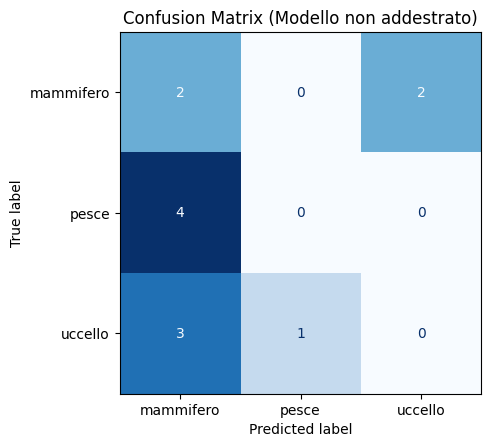

In [18]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true=y_true_labels, y_pred=y_pred_labels,
#    display_labels=display_labels,
    cmap=plt.cm.Blues, normalize=None, ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix (Modello non addestrato)")
plt.tight_layout()
plt.show()

## Alleniamo il modello

In [19]:
import torch.nn 
import torch.optim

In [20]:
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

EPOCHS = 150
loss_history = []
for epoch in range(EPOCHS):
    running_loss = 0
    for x_batch, y_batch in training_set:
        model.train()
        optimizer.zero_grad()
        log_probs = model(x_batch)
        loss = criterion(log_probs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(training_set)
    loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == EPOCHS - 1:
        print(f"Epoca [{epoch+1: >3}/{EPOCHS}], Loss media: {avg_loss:.6f}")


Epoca [  1/150], Loss media: 1.193794
Epoca [ 10/150], Loss media: 0.465917
Epoca [ 20/150], Loss media: 0.244093
Epoca [ 30/150], Loss media: 0.160334
Epoca [ 40/150], Loss media: 0.117631
Epoca [ 50/150], Loss media: 0.092772
Epoca [ 60/150], Loss media: 0.076345
Epoca [ 70/150], Loss media: 0.064745
Epoca [ 80/150], Loss media: 0.056184
Epoca [ 90/150], Loss media: 0.049587
Epoca [100/150], Loss media: 0.044385
Epoca [110/150], Loss media: 0.040154
Epoca [120/150], Loss media: 0.036610
Epoca [130/150], Loss media: 0.033681
Epoca [140/150], Loss media: 0.031168
Epoca [150/150], Loss media: 0.029041


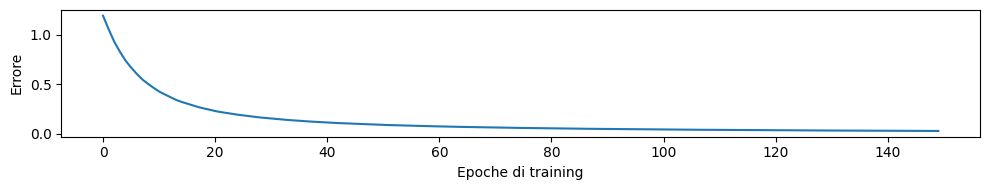

In [21]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(loss_history)
ax.set_xlabel("Epoche di training")
ax.set_ylabel("Errore")
plt.tight_layout()
plt.show()

### Valutazione del modello allenato

In [22]:
model.eval()
prediction = model(X)

y_pred = prediction.argmax(dim=1).detach().numpy()
y_pred_labels = [id_to_label[x] for x in y_pred]
y_true = y.argmax(dim=1).detach().numpy()
y_true_labels = [id_to_label[x] for x in y_true]

print(classification_report(y_true=y_true_labels, y_pred=y_pred_labels, zero_division=0))

              precision    recall  f1-score   support

   mammifero       1.00      1.00      1.00         4
       pesce       1.00      1.00      1.00         4
     uccello       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



In [23]:
model.eval()
prediction_test = model(X_test)

y_pred_test = prediction_test.argmax(dim=1).detach().numpy()
y_pred_test_labels = [id_to_label[x] for x in y_pred_test]
y_true_test = y_test.argmax(dim=1).detach().numpy()
y_true_test_labels = [id_to_label[x] for x in y_true_test]

print(classification_report(y_true=y_true_test_labels, y_pred=y_pred_test_labels, zero_division=0))

              precision    recall  f1-score   support

   mammifero       0.00      0.00      0.00         1
       pesce       0.50      1.00      0.67         1
     uccello       1.00      1.00      1.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



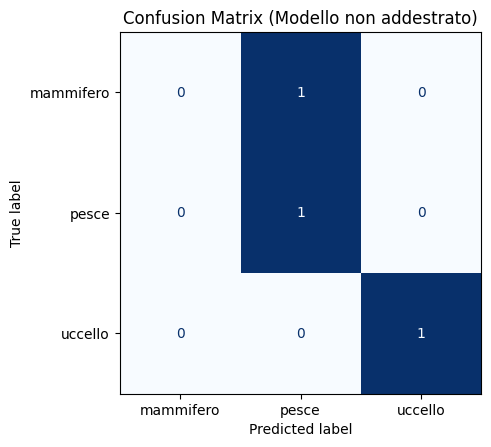

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true=y_true_test_labels, y_pred=y_pred_test_labels,
#    display_labels=display_labels,
    cmap=plt.cm.Blues, normalize=None, ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix (Modello non addestrato)")
plt.tight_layout()
plt.show()

## Cosa impara la macchina?

In [25]:
params = model.linear_layer.weight
print(f"Dimensione dei parametri: {params.shape}")
print(params)

def get_word_vector(word, params):
    wid = word_to_id[word]
    v = params[:,wid].detach().numpy()
    return v 

Dimensione dei parametri: torch.Size([3, 10])
Parameter containing:
tensor([[ 1.8007, -0.9038, -0.6570, -0.2352, -1.0354, -0.2566,  0.9470, -0.2136,
          0.8894, -0.5310],
        [-0.9955,  1.6720, -0.9724,  1.0822, -0.7854, -0.2653, -0.2016,  0.2300,
          0.2202,  1.0475],
        [-0.8059, -0.5177,  1.1996, -0.4445,  1.3400, -0.1464, -0.2039,  0.2651,
         -0.9282, -0.3594]], requires_grad=True)


In [26]:
vocab_vectors = np.array([get_word_vector(w, params) for w in vocab])
V = pd.DataFrame(vocab_vectors, index=vocab)

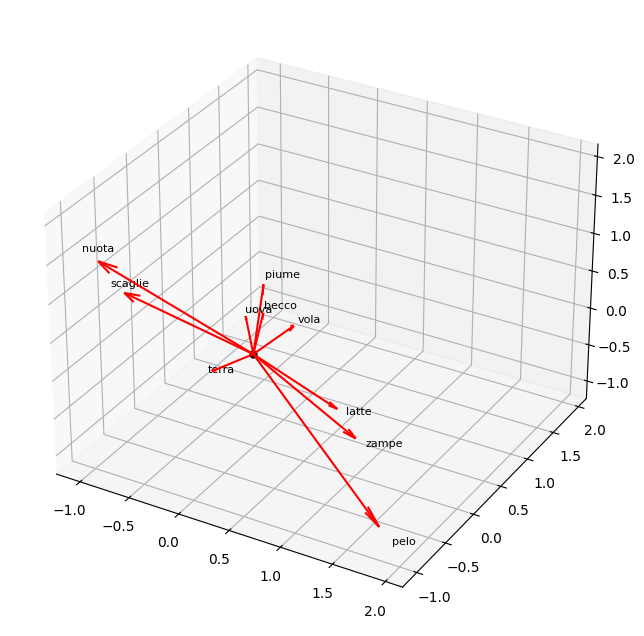

In [27]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for w, row in V.iterrows():
    v = row.values
    ax.quiver(0, 0, 0, v[0], v[1], v[2], 
                  arrow_length_ratio=0.1,
                  color='red')
    ax.text(v[0] * 1.1, v[1] * 1.1, v[2] * 1.1, 
                w, 
                color='black', fontsize=8)
ax.plot([0], [0], [0], 'ko', markersize=5)
max_val = V.max().max() * 1.2
min_val = V.min().min() * 1.2
ax.set_xlim([min_val, max_val])
ax.set_ylim([min_val, max_val])
ax.set_zlim([min_val, max_val])
    
plt.show()

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

In [31]:
V

,0,1,2
pelo,1.800727,-0.995510,-0.805895
piume,-0.903798,1.672037,-0.517656
scaglie,-0.656988,-0.972350,1.199559
vola,-0.235247,1.082193,-0.444475
nuota,-1.035419,-0.785427,1.339956
terra,-0.256626,-0.265342,-0.146367
latte,0.946969,-0.201618,-0.203891
uova,-0.213568,0.229994,0.265125
zampe,0.889350,0.220218,-0.928192
becco,-0.531005,1.047530,-0.359424


In [29]:
S = pd.DataFrame(cosine_similarity(V, V), index=vocab, columns=vocab)
S 

,pelo,piume,scaglie,vola,nuota,terra,latte,uova,zampe,becco
pelo,1.000000,-0.660420,-0.318693,-0.433352,-0.524243,-0.091176,0.946872,-0.911122,0.739157,-0.629821
piume,-0.660420,1.000000,-0.500038,0.958063,-0.291281,-0.173802,-0.557922,0.544070,0.017478,0.999196
scaglie,-0.318693,-0.500038,1.000000,-0.714538,0.974093,0.376711,-0.403936,0.340428,-0.873541,-0.534123
vola,-0.433352,0.958063,-0.714538,1.000000,-0.539595,-0.341284,-0.296716,0.369782,0.283777,0.967696
nuota,-0.524243,-0.291281,0.974093,-0.539595,1.000000,0.375037,-0.593065,0.516013,-0.960159,-0.329121
terra,-0.091176,-0.173802,0.376711,-0.341284,0.375037,1.000000,-0.406404,-0.275979,-0.291188,-0.182640
latte,0.946872,-0.557922,-0.403936,-0.296716,-0.593065,-0.406404,1.000000,-0.744557,0.764889,-0.527284
uova,-0.911122,0.544070,0.340428,0.369782,0.516013,-0.275979,-0.744557,1.000000,-0.719196,0.513347
zampe,0.739157,0.017478,-0.873541,0.283777,-0.960159,-0.291188,0.764889,-0.719196,1.000000,0.057465
becco,-0.629821,0.999196,-0.534123,0.967696,-0.329121,-0.182640,-0.527284,0.513347,0.057465,1.000000


In [32]:
S.loc['vola'].sort_values(ascending=False)

vola       1.000000
becco      0.967696
piume      0.958063
uova       0.369782
zampe      0.283777
latte     -0.296716
terra     -0.341284
pelo      -0.433352
nuota     -0.539595
scaglie   -0.714538
Name: vola, dtype: float32

In [36]:
from sklearn.cluster import AffinityPropagation
from collections import defaultdict

In [34]:
clustering = AffinityPropagation(random_state=5).fit(V)
clusters = clustering.predict(V)

In [37]:
clusters

array([1, 2, 0, 2, 0, 1, 1, 2, 1, 2])

In [38]:
terms = V.index.values
C = defaultdict(list)
for i, cluster in enumerate(clusters):
    C[cluster].append(terms[i])

In [39]:
for cluster, tokens in C.items():
    print(f"Cluster {cluster}: {tokens}")

Cluster 1: ['pelo', 'terra', 'latte', 'zampe']
Cluster 2: ['piume', 'vola', 'uova', 'becco']
Cluster 0: ['scaglie', 'nuota']
